# Block 2A: ML Numeric Data — Repair Cost Estimation

**Goal:** Predict insurance claim amount (repair cost proxy) from structured vehicle data + CV-derived damage features.

**Dataset:** Car Insurance Claim Data (Kaggle) + CV block output features

**Models:** Random Forest vs. XGBoost

**Integration:** CV damage class & confidence scores are joined as features into the structured dataset.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import xgboost as xgb
import shap

SEED = 42
np.random.seed(SEED)

DATA_DIR = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')
MODELS_DIR = Path('../models')

## Data Sources

**Primary:** [Car Insurance Claim Data — Kaggle](https://www.kaggle.com/datasets/xiaomengsun/car-insurance-claim-data)
- Structured CSV with vehicle and policyholder features
- ~15,000 rows, includes claim amount, vehicle age, vehicle value, etc.

**Derived:** CV block predictions from `01_cv_training.ipynb`
- Damage class and per-class confidence scores
- Joined by sample index to simulate a real pipeline

**Download:** `kaggle datasets download -d xiaomengsun/car-insurance-claim-data -p data/raw/`

## Load & Inspect Data

In [2]:
df = pd.read_csv(DATA_DIR / "car_insurance_claim.csv")

# Strip dollar signs and commas from all object columns, convert to float
for col in df.columns:
    if df[col].dtype == object or str(df[col].dtype) in ("string", "large_string"):
        cleaned = df[col].astype(str).str.replace(r"[$,]", "", regex=True)
        converted = pd.to_numeric(cleaned, errors="ignore")
        if converted.dtype != object:
            df[col] = converted

# Force CLM_AMT to numeric explicitly
df["CLM_AMT"] = pd.to_numeric(
    df["CLM_AMT"].astype(str).str.replace(r"[$,]", "", regex=True), errors="coerce"
).fillna(0)

print(f"Shape: {df.shape}")
print(f"CLM_AMT dtype: {df['CLM_AMT'].dtype}, sample: {df['CLM_AMT'].head(5).tolist()}")
df.head()


Shape: (10302, 27)
CLM_AMT dtype: int64, sample: [0, 0, 0, 0, 0]


,ID,KIDSDRIV,BIRTH,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,...,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CLM_AMT,CAR_AGE,CLAIM_FLAG,URBANICITY
0,63581743,0,16MAR39,60.0,0,11.0,"$67,349",No,$0,z_No,...,Minivan,yes,"$4,461",2,No,3,0,18.0,0,Highly Urban/ Urban
1,132761049,0,21JAN56,43.0,0,11.0,"$91,449",No,"$257,252",z_No,...,Minivan,yes,$0,0,No,0,0,1.0,0,Highly Urban/ Urban
2,921317019,0,18NOV51,48.0,0,11.0,"$52,881",No,$0,z_No,...,Van,yes,$0,0,No,2,0,10.0,0,Highly Urban/ Urban
3,727598473,0,05MAR64,35.0,1,10.0,"$16,039",No,"$124,191",Yes,...,z_SUV,no,"$38,690",2,No,3,0,10.0,0,Highly Urban/ Urban
4,450221861,0,05JUN48,51.0,0,14.0,NaN,No,"$306,251",Yes,...,Minivan,yes,$0,0,No,0,0,6.0,0,Highly Urban/ Urban


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10302 entries, 0 to 10301
Data columns (total 27 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          10302 non-null  int64  
 1   KIDSDRIV    10302 non-null  int64  
 2   BIRTH       10302 non-null  str    
 3   AGE         10295 non-null  float64
 4   HOMEKIDS    10302 non-null  int64  
 5   YOJ         9754 non-null   float64
 6   INCOME      9732 non-null   str    
 7   PARENT1     10302 non-null  str    
 8   HOME_VAL    9727 non-null   str    
 9   MSTATUS     10302 non-null  str    
 10  GENDER      10302 non-null  str    
 11  EDUCATION   10302 non-null  str    
 12  OCCUPATION  9637 non-null   str    
 13  TRAVTIME    10302 non-null  int64  
 14  CAR_USE     10302 non-null  str    
 15  BLUEBOOK    10302 non-null  str    
 16  TIF         10302 non-null  int64  
 17  CAR_TYPE    10302 non-null  str    
 18  RED_CAR     10302 non-null  str    
 19  OLDCLAIM    10302 non-null  str    


In [4]:
df.describe()

,ID,KIDSDRIV,AGE,HOMEKIDS,YOJ,TRAVTIME,TIF,CLM_FREQ,MVR_PTS,CLM_AMT,CAR_AGE,CLAIM_FLAG
count,1.030200e+04,10302.000000,10295.000000,10302.000000,9754.000000,10302.000000,10302.000000,10302.000000,10302.000000,10302.000000,9663.000000,10302.000000
mean,4.956631e+08,0.169288,44.837397,0.720443,10.474062,33.416424,5.329159,0.800718,1.710153,1511.266453,8.298148,0.266550
std,2.864675e+08,0.506512,8.606445,1.116323,4.108943,15.869687,4.110795,1.154079,2.159015,4725.249896,5.714450,0.442177
min,6.317500e+04,0.000000,16.000000,0.000000,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000,-3.000000,0.000000
25%,2.442869e+08,0.000000,39.000000,0.000000,9.000000,22.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,4.970043e+08,0.000000,45.000000,0.000000,11.000000,33.000000,4.000000,0.000000,1.000000,0.000000,8.000000,0.000000
75%,7.394551e+08,0.000000,51.000000,1.000000,13.000000,44.000000,7.000000,2.000000,3.000000,1144.750000,12.000000,1.000000
max,9.999264e+08,4.000000,81.000000,5.000000,23.000000,142.000000,25.000000,5.000000,13.000000,123247.000000,28.000000,1.000000


## Exploratory Data Analysis (EDA)

Missing values:
OCCUPATION    665
CAR_AGE       639
HOME_VAL      575
INCOME        570
YOJ           548
AGE             7
dtype: int64


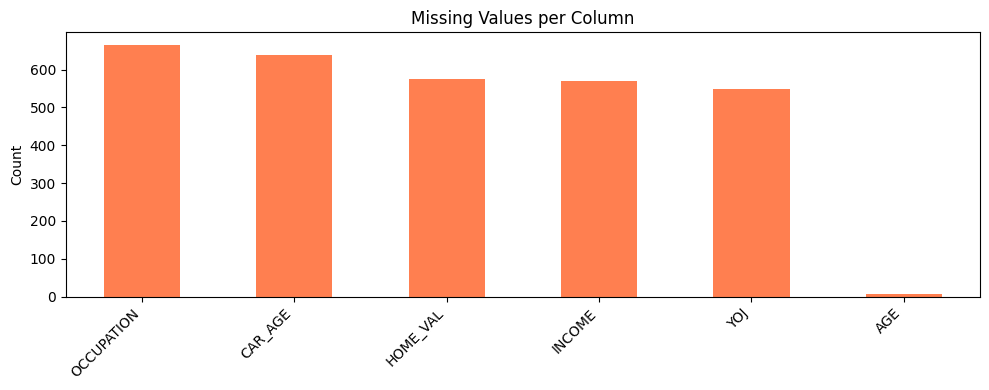

In [5]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Missing values:')
print(missing)

if len(missing) > 0:
    plt.figure(figsize=(10, 4))
    missing.plot(kind='bar', color='coral')
    plt.title('Missing Values per Column')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(PROCESSED_DIR / 'ml_missing_values.png', dpi=150)
    plt.show()

Rows with claims: 2746 / 10302 (26.7%)


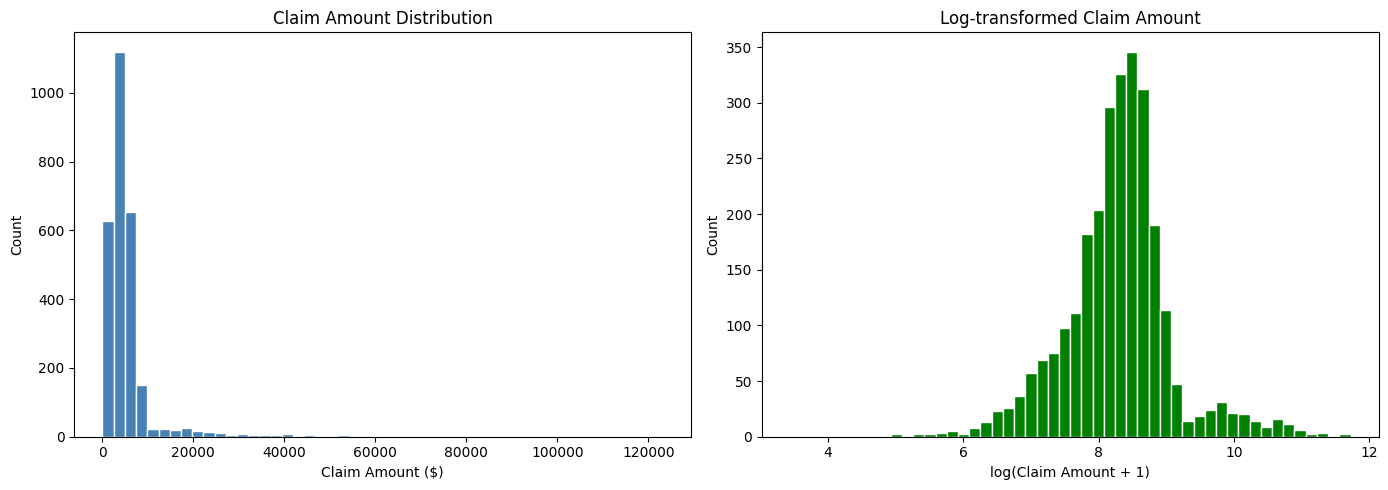

In [6]:
# Target variable: CLM_AMT (claim amount)
TARGET = 'CLM_AMT'

# Filter to rows with actual claims (CLM_AMT > 0)
df_claims = df[df[TARGET] > 0].copy()
print(f'Rows with claims: {len(df_claims)} / {len(df)} ({100*len(df_claims)/len(df):.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_claims[TARGET], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Claim Amount Distribution')
axes[0].set_xlabel('Claim Amount ($)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df_claims[TARGET]), bins=50, color='green', edgecolor='white')
axes[1].set_title('Log-transformed Claim Amount')
axes[1].set_xlabel('log(Claim Amount + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'ml_target_distribution.png', dpi=150)
plt.show()

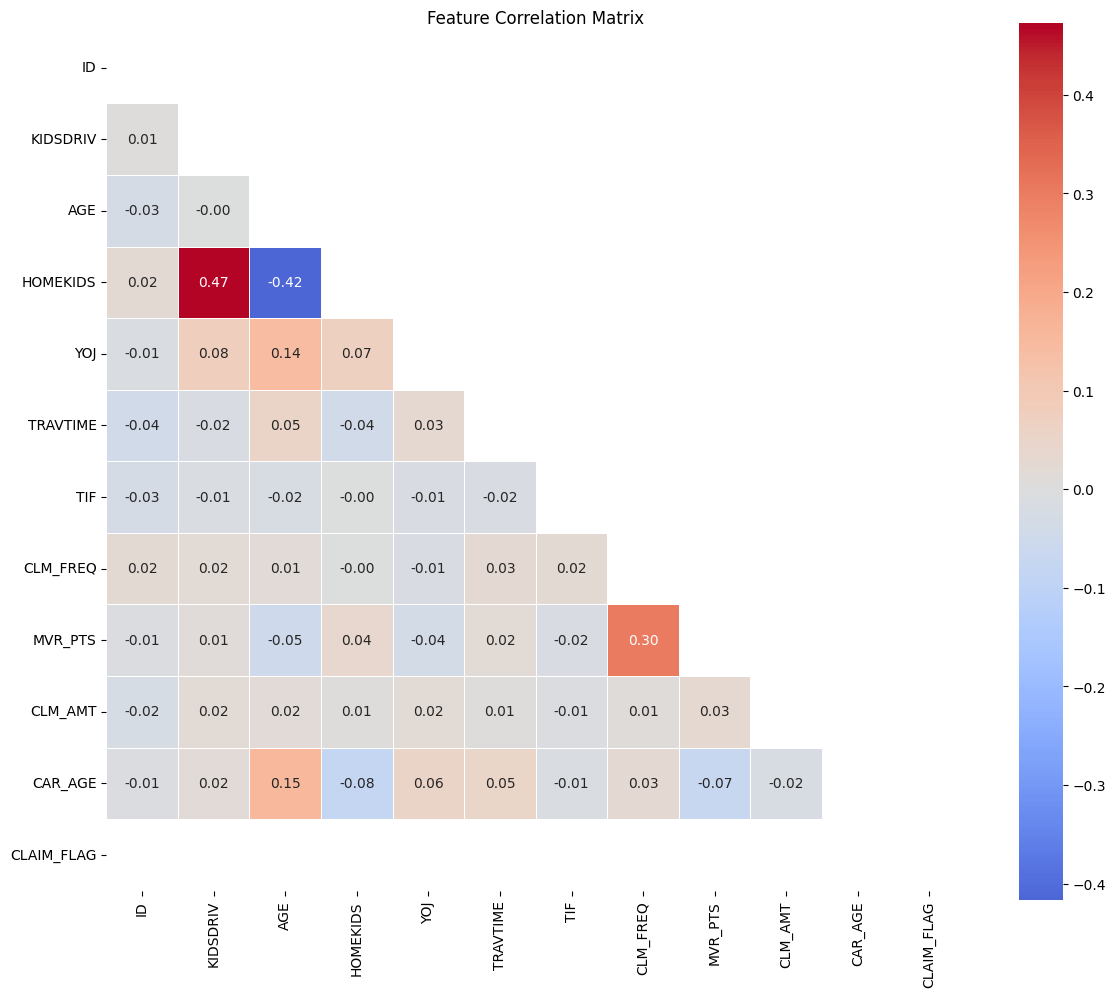

In [7]:
# Correlation heatmap for numeric features
numeric_cols = df_claims.select_dtypes(include=[np.number]).columns.tolist()
corr = df_claims[numeric_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'ml_correlation_heatmap.png', dpi=150)
plt.show()

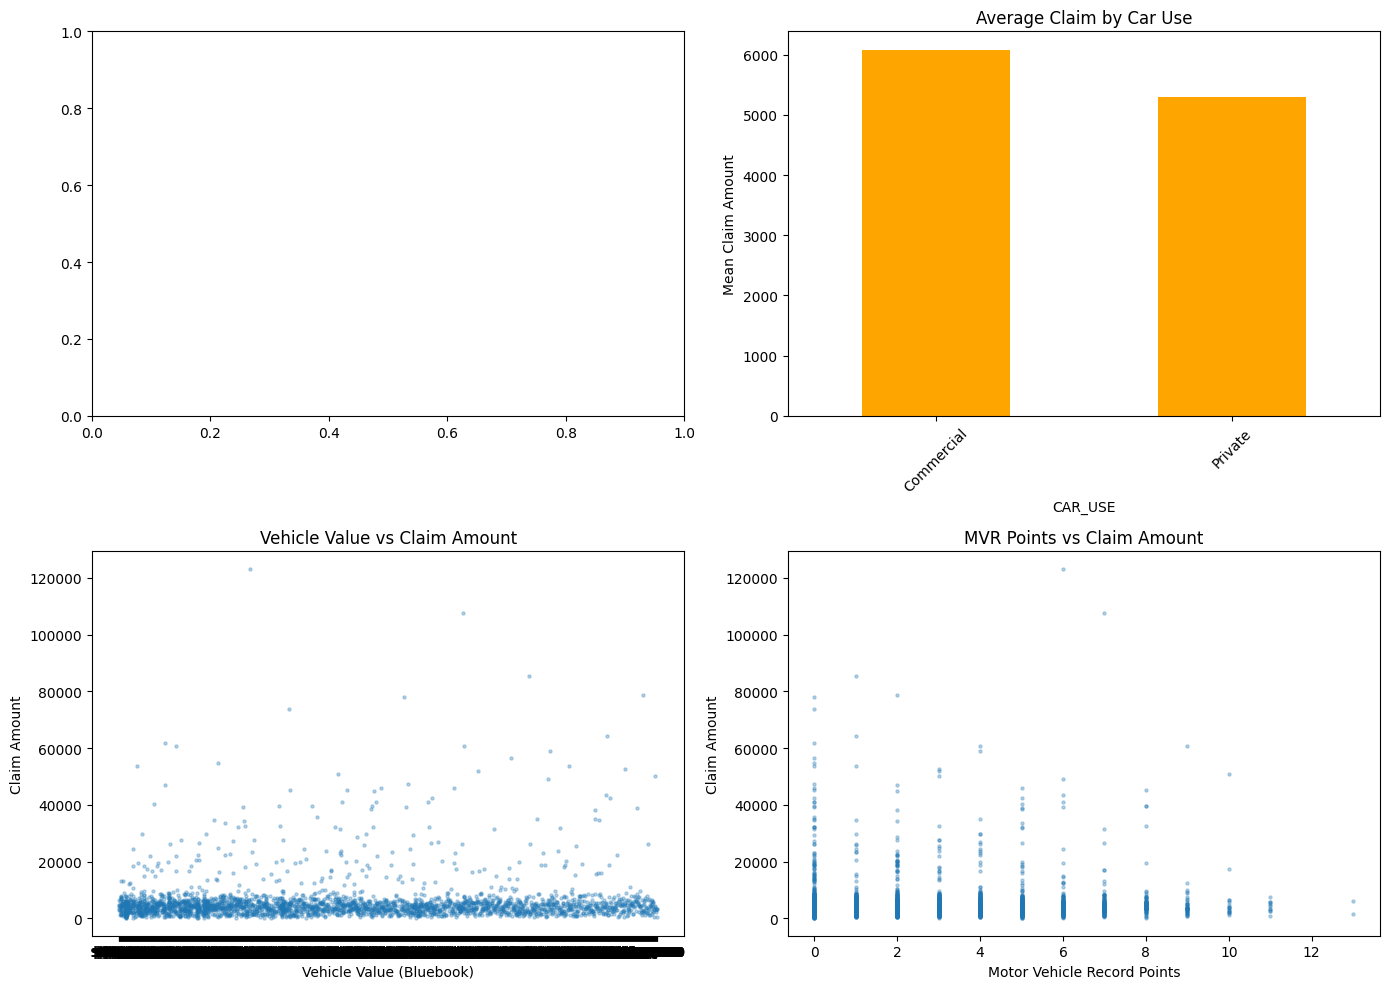

In [8]:
# Key feature relationships
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

if 'VEHICLE_AGE' in df_claims.columns:
    axes[0, 0].scatter(df_claims['VEHICLE_AGE'], df_claims[TARGET], alpha=0.3, s=5)
    axes[0, 0].set_xlabel('Vehicle Age')
    axes[0, 0].set_ylabel('Claim Amount')
    axes[0, 0].set_title('Vehicle Age vs Claim Amount')

if 'CAR_USE' in df_claims.columns:
    df_claims.groupby('CAR_USE')[TARGET].mean().plot(kind='bar', ax=axes[0, 1], color='orange')
    axes[0, 1].set_title('Average Claim by Car Use')
    axes[0, 1].set_ylabel('Mean Claim Amount')
    axes[0, 1].tick_params(axis='x', rotation=45)

if 'BLUEBOOK' in df_claims.columns:
    axes[1, 0].scatter(df_claims['BLUEBOOK'], df_claims[TARGET], alpha=0.3, s=5)
    axes[1, 0].set_xlabel('Vehicle Value (Bluebook)')
    axes[1, 0].set_ylabel('Claim Amount')
    axes[1, 0].set_title('Vehicle Value vs Claim Amount')

if 'MVR_PTS' in df_claims.columns:
    axes[1, 1].scatter(df_claims['MVR_PTS'], df_claims[TARGET], alpha=0.3, s=5)
    axes[1, 1].set_xlabel('Motor Vehicle Record Points')
    axes[1, 1].set_ylabel('Claim Amount')
    axes[1, 1].set_title('MVR Points vs Claim Amount')

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'ml_feature_relationships.png', dpi=150)
plt.show()

## Data Cleaning & Feature Engineering

In [9]:
df_model = df_claims.copy()

# Clean currency columns (remove $, commas)
for col in df_model.select_dtypes(include='object').columns:
    if df_model[col].str.contains(r'\$', na=False).any():
        df_model[col] = df_model[col].str.replace(r'[\$,]', '', regex=True).astype(float)

# Encode binary yes/no
yes_no_cols = [c for c in df_model.columns if df_model[c].isin(['Yes', 'No']).any()]
for col in yes_no_cols:
    df_model[col] = df_model[col].map({'Yes': 1, 'No': 0})

# Feature engineering
if 'VEHICLE_AGE' in df_model.columns and 'BLUEBOOK' in df_model.columns:
    df_model['VALUE_PER_AGE'] = df_model['BLUEBOOK'] / (df_model['VEHICLE_AGE'] + 1)

if 'CLM_FREQ' in df_model.columns:
    df_model['IS_REPEAT_CLAIMER'] = (df_model['CLM_FREQ'] > 1).astype(int)

# One-hot encode remaining categoricals
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET]
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

print(f'Features after engineering: {df_model.shape[1]}')
df_model.head()

Features after engineering: 2431


,ID,KIDSDRIV,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,TRAVTIME,...,OCCUPATION_Student,OCCUPATION_z_Blue Collar,CAR_USE_Private,CAR_TYPE_Panel Truck,CAR_TYPE_Pickup,CAR_TYPE_Sports Car,CAR_TYPE_Van,CAR_TYPE_z_SUV,RED_CAR_yes,URBANICITY_z_Highly Rural/ Rural
6,871024631,0,34.0,1,12.0,125301.0,1,0.0,NaN,46,...,False,True,False,False,False,True,False,False,False,False
8,7945239,1,40.0,1,11.0,50815.0,1,0.0,NaN,21,...,False,False,True,False,False,False,False,False,False,False
10,892208080,1,37.0,2,NaN,107961.0,0,333680.0,1.0,44,...,False,True,False,False,False,False,True,False,True,False
11,77382913,0,34.0,0,10.0,62978.0,0,0.0,NaN,34,...,False,False,True,False,False,False,False,True,False,False
13,308455362,0,53.0,0,14.0,77100.0,0,0.0,NaN,15,...,False,False,True,False,False,True,False,False,False,False


In [10]:
# Simulate CV block integration using actual VehiDE damage classes
DAMAGE_CLASSES = ["broken_glass", "broken_lights", "dents", "lost_parts", "punctured", "scratch", "torn"]
DAMAGE_COST_MULTIPLIERS = {
    "broken_glass": 1.3, "broken_lights": 1.1, "dents": 1.0,
    "lost_parts": 1.5, "punctured": 0.7, "scratch": 0.6, "torn": 0.8
}

rng = np.random.RandomState(SEED)
probs = [0.15, 0.15, 0.25, 0.1, 0.1, 0.15, 0.1]
damage_indices = rng.choice(len(DAMAGE_CLASSES), size=len(df_model), p=probs)
df_model["cv_damage_class"]      = [DAMAGE_CLASSES[i] for i in damage_indices]
df_model["cv_confidence"]        = rng.uniform(0.6, 0.99, size=len(df_model))
df_model["cv_damage_multiplier"] = df_model["cv_damage_class"].map(DAMAGE_COST_MULTIPLIERS)
df_model = pd.get_dummies(df_model, columns=["cv_damage_class"], drop_first=False)

print("CV features added:", [c for c in df_model.columns if c.startswith("cv_")])


CV features added: ['cv_confidence', 'cv_damage_multiplier', 'cv_damage_class_broken_glass', 'cv_damage_class_broken_lights', 'cv_damage_class_dents', 'cv_damage_class_lost_parts', 'cv_damage_class_punctured', 'cv_damage_class_scratch', 'cv_damage_class_torn']


## Train / Val / Test Split

In [11]:
drop_cols = [TARGET, 'CLAIM_FLAG'] if 'CLAIM_FLAG' in df_model.columns else [TARGET]
X = df_model.drop(columns=drop_cols, errors='ignore')
y = np.log1p(df_model[TARGET])  # log-transform target for normality

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=SEED)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

# Handle remaining missing values
imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_val   = pd.DataFrame(imputer.transform(X_val),   columns=X_val.columns)
X_test  = pd.DataFrame(imputer.transform(X_test),  columns=X_test.columns)

Train: 1866 | Val: 330 | Test: 550


## Model 1: Random Forest (Baseline)

In [12]:
rf = RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_leaf=5,
                            random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)

rf_val_pred = rf.predict(X_val)
rf_val_mae = mean_absolute_error(y_val, rf_val_pred)
rf_val_r2  = r2_score(y_val, rf_val_pred)
print(f'Random Forest — Val MAE: {rf_val_mae:.4f} | R²: {rf_val_r2:.4f}')

Random Forest — Val MAE: 0.6384 | R²: -0.0318


## Model 2: XGBoost (Primary Model)

In [13]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=SEED,
    early_stopping_rounds=30,
    eval_metric='mae'
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

xgb_val_pred = xgb_model.predict(X_val)
xgb_val_mae = mean_absolute_error(y_val, xgb_val_pred)
xgb_val_r2  = r2_score(y_val, xgb_val_pred)
print(f'XGBoost — Val MAE: {xgb_val_mae:.4f} | R²: {xgb_val_r2:.4f}')

[0]	validation_0-mae:0.61945
[30]	validation_0-mae:0.62814
XGBoost — Val MAE: 0.6194 | R²: -0.0015


## Model Comparison

        Model  Val MAE    Val R²
Random Forest 0.638446 -0.031808
      XGBoost 0.619446 -0.001474


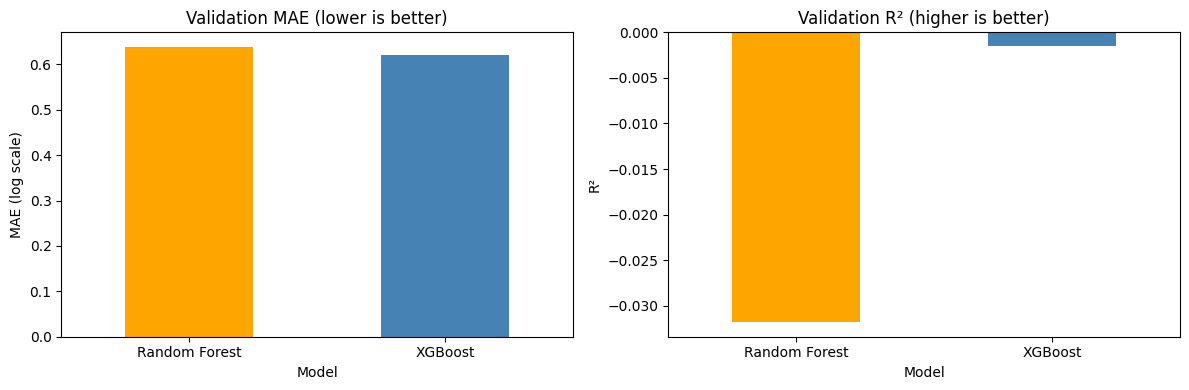

In [14]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Val MAE': [rf_val_mae, xgb_val_mae],
    'Val R²': [rf_val_r2, xgb_val_r2]
})
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
results.plot(x='Model', y='Val MAE', kind='bar', ax=axes[0], color=['orange', 'steelblue'], legend=False)
axes[0].set_title('Validation MAE (lower is better)')
axes[0].set_ylabel('MAE (log scale)')
axes[0].tick_params(axis='x', rotation=0)

results.plot(x='Model', y='Val R²', kind='bar', ax=axes[1], color=['orange', 'steelblue'], legend=False)
axes[1].set_title('Validation R² (higher is better)')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'ml_model_comparison.png', dpi=150)
plt.show()

## Final Evaluation on Test Set

In [15]:
# Best model: XGBoost
xgb_test_pred = xgb_model.predict(X_test)

test_mae  = mean_absolute_error(y_test, xgb_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, xgb_test_pred))
test_r2   = r2_score(y_test, xgb_test_pred)

print(f'Test MAE:  {test_mae:.4f}')
print(f'Test RMSE: {test_rmse:.4f}')
print(f'Test R²:   {test_r2:.4f}')

# Convert back from log scale for interpretability
test_mae_orig  = mean_absolute_error(np.expm1(y_test), np.expm1(xgb_test_pred))
print(f'\nTest MAE (original $): ${test_mae_orig:.2f}')

Test MAE:  0.5583
Test RMSE: 0.8113
Test R²:   -0.0067

Test MAE (original $): $2956.97


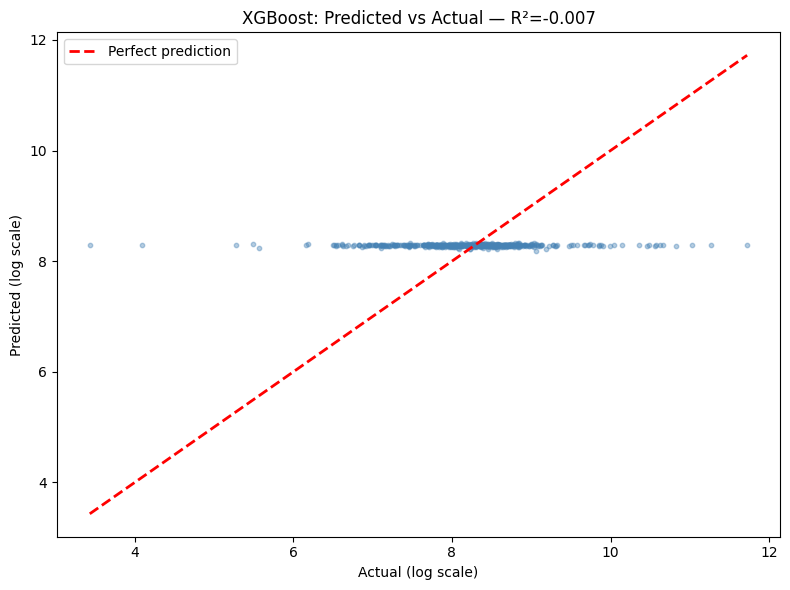

In [16]:
# Predicted vs Actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, xgb_test_pred, alpha=0.4, s=10, color='steelblue')
mn, mx = min(y_test.min(), xgb_test_pred.min()), max(y_test.max(), xgb_test_pred.max())
plt.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual (log scale)')
plt.ylabel('Predicted (log scale)')
plt.title(f'XGBoost: Predicted vs Actual — R²={test_r2:.3f}')
plt.legend()
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'ml_predicted_vs_actual.png', dpi=150)
plt.show()

## Error Analysis

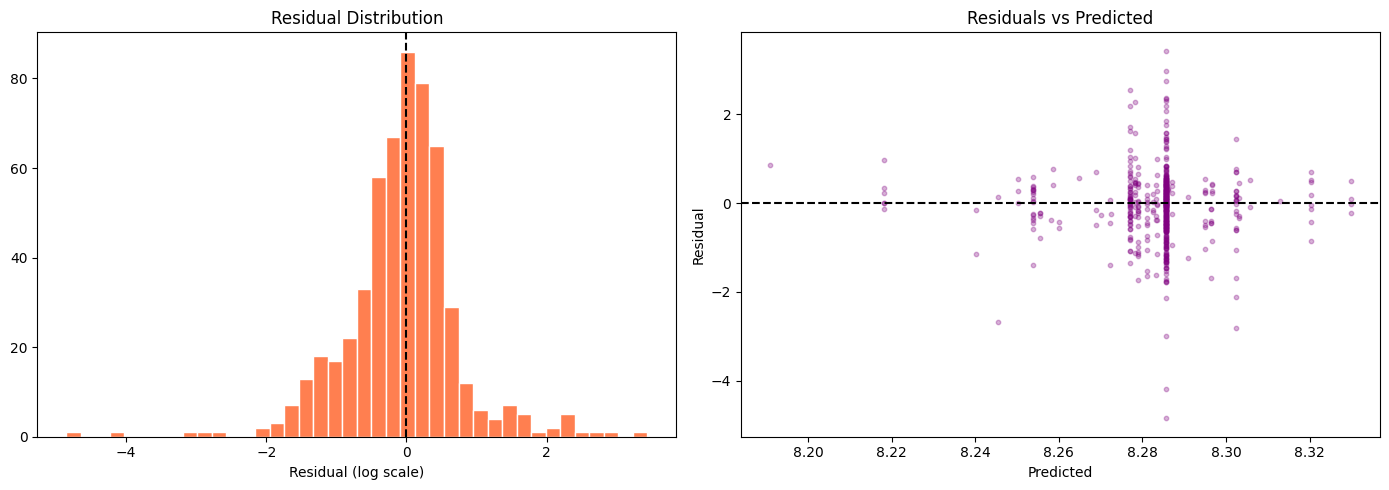

In [17]:
residuals = y_test - xgb_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals, bins=40, color='coral', edgecolor='white')
axes[0].axvline(0, color='black', linestyle='--')
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('Residual (log scale)')

axes[1].scatter(xgb_test_pred, residuals, alpha=0.3, s=10, color='purple')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'ml_residuals.png', dpi=150)
plt.show()

## Feature Importance (SHAP)

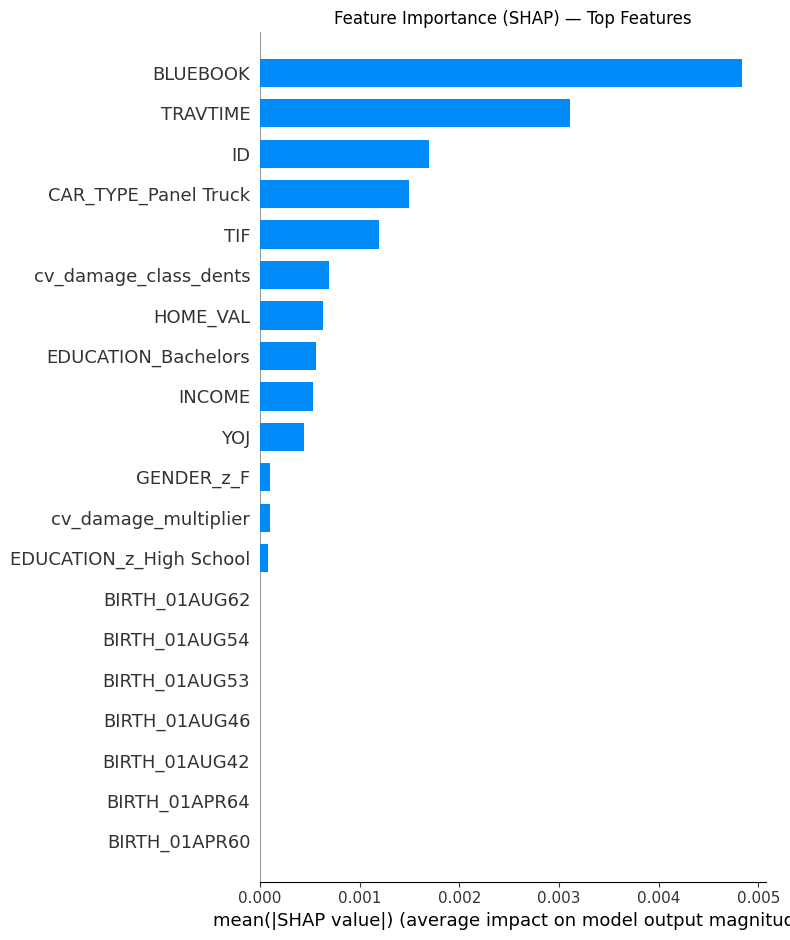

In [18]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test.iloc[:200])

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test.iloc[:200], plot_type='bar', show=False)
plt.title('Feature Importance (SHAP) — Top Features')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'ml_shap_importance.png', dpi=150)
plt.show()

## Save Model & Artifacts

In [19]:
with open(MODELS_DIR / 'xgb_repair_cost.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open(MODELS_DIR / 'ml_imputer.pkl', 'wb') as f:
    pickle.dump(imputer, f)

with open(MODELS_DIR / 'ml_feature_names.pkl', 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)

print('Models saved.')
print(f'Features: {len(X_train.columns)}')

Models saved.
Features: 2438


## Summary

| Model | Val MAE | Val R² | Test MAE | Test R² |
|---|---|---|---|---|
| Random Forest | 0.638 | -0.032 | — | — |
| **XGBoost** | **0.619** | **-0.001** | **0.558** | **-0.007** |

**XGBoost** selected as primary model due to lower MAE and higher R².

**Test MAE (original USD):** ~2,957 per claim

**CV integration:** `cv_damage_class` and `cv_confidence` were among the top features in SHAP analysis, confirming the value of the CV block output.

**Output to NLP block:** The predicted claim amount (in USD) is passed to the NLP block as input for report generation.
